In [1]:
import re
from datasets import load_dataset

dat = load_dataset("ncbi/Open-Patients", split="train")
df = dat.to_pandas()
df.head()


/Users/vuong/Downloads/research/repos/ClinicNumRobBench/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,_id,description
0,trec-cds-2014-1,A 58-year-old African-American woman presents ...
1,trec-cds-2014-2,An 8-year-old male presents in March to the ER...
2,trec-cds-2014-3,A 58-year-old nonsmoker white female with mild...
3,trec-cds-2014-4,A 2-year-old boy is brought to the emergency d...
4,trec-cds-2014-5,A 56-year-old female on 20th day post-left mas...


In [2]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 10)

In [3]:
df[df['description'].str.lower().str.contains('year old|year-old')]

,_id,description
0,trec-cds-2014-1,"A 58-year-old African-American woman presents to the ER with episodic pressing/burning anterior chest pain that began two days earlier for the first time in her life. The pain started while she was walking, radiates to the back, and is accompanied by nausea, diaphoresis and mild dyspnea, but is not increased on inspiration. The latest episode of pain ended half an hour prior to her arrival. She is known to have hypertension and obesity. She denies smoking, diabetes, hypercholesterolemia, or a family history of heart disease. She currently takes no medications. Physical examination is normal. The EKG shows nonspecific changes."
1,trec-cds-2014-2,"An 8-year-old male presents in March to the ER with fever up to 39 C, dyspnea and cough for 2 days. He has just returned from a 5 day vacation in Colorado. Parents report that prior to the onset of fever and cough, he had loose stools. He denies upper respiratory tract symptoms. On examination he is in respiratory distress and has bronchial respiratory sounds on the left. A chest x-ray shows bilateral lung infiltrates."
2,trec-cds-2014-3,"A 58-year-old nonsmoker white female with mild exertional dyspnea and occasional cough is found to have a left lung mass on chest x-ray. She is otherwise asymptomatic. A neurologic examination is unremarkable, but a CT scan of the head shows a solitary mass in the right frontal lobe."
3,trec-cds-2014-4,"A 2-year-old boy is brought to the emergency department by his parents for 5 days of high fever and irritability. The physical exam reveals conjunctivitis, strawberry tongue, inflammation of the hands and feet, desquamation of the skin of the fingers and toes, and cervical lymphadenopathy with the smallest node at 1.5 cm. The abdominal exam demonstrates tenderness and enlarged liver. Laboratory tests report elevated alanine aminotransferase, white blood cell count of 17,580/mm, albumin 2.1 g/dL, C-reactive protein 4.5 mg, erythrocyte sedimentation rate 60 mm/h, mild normochromic, normocytic anemia, and leukocytes in urine of 20/mL with no bacteria identified. The echocardiogram shows moderate dilation of the coronary arteries with possible coronary artery aneurysm."
4,trec-cds-2014-5,"A 56-year-old female on 20th day post-left mastectomy presents to the emergency department complaining of shortness of breath and malaise. The patient says that she has remained in bed for the last two weeks. The physical examination reveals tenderness on the left upper thoracic wall and right calf. The surgical incision shows no bleeding or signs of infection. Pulmonary auscultation is significant for bilateral decreased breath sounds, especially at the right base. Laboratory tests reveal an elevated D-dimer."
...,...,...
180137,usmle-12888,"A 26-year-old female who is 12 weeks pregnant presents to her primary care physician because she is concerned about her acne. While she has struggled with acne for most of her adult life, the acne has become more severe in the past few months. She has used benzoyl peroxide, salicylic acid, and topical antibiotics in the past but these treatments have had little effect. The patient would like to try minocycline, which worked for a friend of hers. The physician responds that this drug cannot be given to pregnant women, and offers to start the patient on the drug after she delivers the baby. Minocycline may to toxic to the fetus through which mechanism?"
180138,usmle-12889,"A 9-year-old boy is brought to the clinic by his parents for an annual wellness examination. He is a relatively healthy boy who was born at term via vaginal delivery. He is meeting his developmental milestones and growth curves and is up-to-date on his immunizations. The father complains that he is picky with his food and would rather eat pizza. The patient denies any trouble at school, fevers, pain, or other concerns. A physical examination demonstrates a healthy boy with a grade 3 midsystolic ejection murmur at the second interco

## Filtering

In [4]:
vital_sign_pattern = 'vital sign|vitals|vitals sign'
number_contain_pattern = r'(\d+[^\d]+\d*){5,}'
year_old_pattern = 'year old|year-old|years old|years-old|yr-old|yr old'

In [5]:
vts_df = df[df['description'].str.lower().str.contains(vital_sign_pattern)]
print("Numbers of notes with `vital sign` keyword: ",vts_df.__len__())
print("Ratio of notes with `vital sign` keyword: ",vts_df.__len__()/df.__len__())
print("Ratio of notes with `year old|year-old|years old|years-old|yr-old|yr old` keyword: ",df[df['description'].str.lower().str.contains(year_old_pattern)].__len__()/df.__len__())
print("Ratio of notes with `(\d+[^\d]+\d*){3,}` pattern: ",df[df['description'].str.lower().str.contains(number_contain_pattern)].__len__()/df.__len__())

Numbers of notes with `vital sign` keyword:  16676
Ratio of notes with `vital sign` keyword:  0.09257141588302562
Ratio of notes with `year old|year-old|years old|years-old|yr-old|yr old` keyword:  0.9645668417137592


/var/folders/hz/5nlzxq9x1_d8xyj_m399s8g80000gn/T/ipykernel_86584/1429143617.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  print("Ratio of notes with `(\d+[^\d]+\d*){3,}` pattern: ",df[df['description'].str.lower().str.contains(number_contain_pattern)].__len__()/df.__len__())


Ratio of notes with `(\d+[^\d]+\d*){3,}` pattern:  0.8812492367132595


In [6]:
filted_df =df[df['description'].str.lower().map(lambda note: (bool(re.search(vital_sign_pattern, note)) 
                                                and bool(re.search(number_contain_pattern, note)) 
                                                and bool(re.search(year_old_pattern, note))
                                                ) )
]
filted_df

,_id,description
38,trec-cds-2015-9,"A 10 year old child is brought to the emergency room complaining of myalgia, cough, and shortness of breath. Two weeks ago the patient was seen by his pediatrician for low-grade fever, abdominal pain, and diarrhea, diagnosed with a viral illness, and prescribed OTC medications. Three weeks ago the family returned home after a stay with relatives on a farm that raises domestic pigs for consumption. Vital signs: T: 39.5 C, BP: 90/60 HR: 120/min RR: 40/min. Physical exam findings include cyanosis, slight stiffness of the neck, and marked periorbital edema. Lab results include WBC 25,000, with 25% Eosinophils, and an unremarkable urinalysis."
79,trec-cds-2016-20,"A 87 year old female NH resident with a history of chronic atrial fibrillation, hypertension and hypothyroidism who presents wit abdominal pain. She had been in her usual state of health until 5 days ago when she suddenly began to have abdominal pain. Her abdominal pain was initially intermittent lasting for a few hours at at time. No clear correlation with food. Yesterday, she noticed that her pain was much more severe and more localized to the right. This was accompanied by nausea and vomitting. She vomitted twice, with clear liquid emesis and was sent to a hospital. At the hospital, she was noted to have elevated amylase/lipase to 538 and 516 with elevated bili to 4.1 and AST/ALT to 198/115 and was given ciprofloxacin, flagyl and 500cc NS and was transferred to the emergency department. At the emergency department her vital signs were TM 97.9 HR 83 BP 157/92 RR 18 sat 97% RA."
117,trec-ct-2021-28,"The patient is a 60-year-old Spanish man presenting with shortness of breath about a day before. The symptoms began acutely and progressively worsened. He is a known case of COPD since 2 years ago. The spirometry revealed post-bronchodilator FEV1/FVC = 60% of predicted values. He smokes 20 cigarette per day. His past medical history is remarkable for BPH and he is using Flomax for that. His family history is positive for HTN in his brother. His medication includes Duo-Neb inhaled q4 hr PRN, Vit D3 1000 units per day and Flomax for his PBH. He is an obese man who is acutely ill but oriented and conscious. The vital signs are as bellow:\nBP: 135/80\nRR: 25/min\nHR: 75 bpm\nBMI: 40\nO2sat: 90%"
136,trec-ct-2021-47,"A 62-year-old African-American man presented with left upper and lower extremity weakness, associated with dark visual spot in right eye, right facial numbness, facial drop and slurred speech. He denied dyspnea, headache, palpitations, chest pain, fever, dizziness, bowel or urinary incontinence, loss of consciousness. His medical history was significant for hypertension, hyperlipidemia and hypothyroidism. He smokes cigarette 1 pack per day for 40 years and alcohol consumption of 5 to 6 beers per week. He is not aware about his family history. He is using Levothyroxine, Atorvastatin and HTCZ. His vital signs were stable in the primary evaluation. Left-sided facial droop, dysarthria, and left-sided hemiplegia were seen in the physical exam. His National Institutes of Health Stroke Scale (NIHSS) score was calculated as 7. Initial CT angiogram of head and neck reported no acute intracranial findings. Intravenous recombinant tissue plasminogen activator (t-PA) was administered as well as high-dose statin therapy. The patient was admitted to the intensive care unit to be monitored for 24 hours. MRI of the head revealed an acute 1.7-cm infarct of the right periventricular white matter and posterior right basal ganglia."
140,trec-ct-2021-51,"The patients is a 25-year-old G1 P1 pregnant woman who is 24W3D gestational old who developed a sudden unset of fever and chills, accompany with nausea and vomiting. She also complains of dysuria, urgency and frequency. She also reports some severe pain in the flank. Her vital signs are: T = 39.7ºC, P = 117, R = 20, and BP = 113/74 mm Hg. Physical examination reveals tenderness on palpation of both cos

# Medcalc

In [7]:
medcalc_df = load_dataset("ncbi/MedCalc-Bench-v1.1", split="test").to_pandas()
medcalc_df = medcalc_df[['Row Number','Patient Note', 'Relevant Entities']]
medcalc_df.head()

Row Number  \
0           1   
1           2   
2           3   
3           4   
4           5   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [8]:
import re

print(medcalc_df.__len__())
# medcalc_df[~medcalc_df['Patient Note'].str.lower().str.contains('year old|year-old|years old|years-old|yr-old|yr old')]
# medcalc_df[medcalc_df['Patient Note'].map(lambda x: bool(re.search(r'vital sign', x)))]
# medcalc_df[medcalc_df['Patient Note'].str.lower().str.contains(r'\d+\w+\d+')]
medcalc_df[medcalc_df['Patient Note'].map(lambda x: bool(re.search(vital_sign_pattern, x)) and bool(re.search(number_contain_pattern, x)) and bool(re.search(year_old_pattern, x)))]

1100


Row Number  \
1             2   
14           15   
35           36   
42           43   
51           52   
..          ...   
930         931   
934         935   
936         937   
947         948   
959         960   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

# Map our data based on Age

In [10]:
import os
for task in ['retrieval', 'calculation', 'comparison','summary']:
    for subtask in os.listdir(f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}"):
        file_path = f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}/{subtask}"
        our_df = pd.read_csv(file_path)
        our_df['age'] = our_df['question'].map(lambda x: x[re.search(r'age: (\d+)', x).span()[0]+5:re.search(r'age: (\d+)', x).span()[1]])
        our_df['mapping_num'] = our_df.age.map(lambda age: filted_df[filted_df['description'].str.lower().map(lambda x: bool(re.search(f'{age} year old|{age}-year-old|{age} years old|{age}-years-old|{age}-yr-old|{age} yr old', x)))].__len__())
        # print(our_df.mapping_num.value_counts().sort_index())
        # print(our_df.mapping_num.value_counts())
        print(f"Min mapping {subtask}: ",our_df.mapping_num.min())

Min mapping direct_retrieval.csv:  16
Min mapping calculation_1step.csv:  3
Min mapping calculation_2step.csv:  3
Min mapping calculation_3step.csv:  1
Min mapping comparison_superlative.csv:  15
Min mapping comparison_comparative.csv:  15
Min mapping superlative.csv:  15
Min mapping comparative.csv:  15
Min mapping summary.csv:  3


# Check extraction data

After run `python clinicnumrobbench/data_creation/extract_vital_sign_open_patients.py --model-name gpt-4.1-mini --batch-size 4 --output-path data/open_patients_extracted_vital_sign.csv`
We have file `data/open_patients_extracted_vital_sign_raw.csv`

In [118]:
import pandas as pd
df = pd.read_csv("/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/open_patients_extracted_vital_sign_raw.csv")
print(df.__len__())
df.head(2)

15046


,_id,description,extracted_vital_sign_text,extracted_vital_sign_json
0,trec-cds-2015-9,A 10 year old child is brought to the emergenc...,"T: 39.5 C, BP: 90/60 HR: 120/min RR: 40/min","{'temperature': {'text': 'T: 39.5 C', 'number'..."
1,trec-cds-2016-20,A 87 year old female NH resident with a histor...,TM 97.9 HR 83 BP 157/92 RR 18 sat 97% RA,"{'temperature': {'text': 'TM 97.9', 'number': ..."


## Check samples having all attributes in vital signs

In [119]:
df[df['extracted_vital_sign_text'].notna()].__len__()

9946

In [120]:
df[df["extracted_vital_sign_json"].map(eval).map(lambda x: isinstance(x, dict) and all(value['number'] is not None for value in x.values()))].__len__()

2437

## Check samples having no attribute in vital signs

In [121]:

non_df = df[df["extracted_vital_sign_json"].map(eval).map(lambda x: isinstance(x, dict) and all(value['number'] is None for value in x.values()))]
print(non_df.__len__())
non_df.head(2)

5441


,_id,description,extracted_vital_sign_text,extracted_vital_sign_json
3,trec-ct-2021-47,A 62-year-old African-American man presented w...,NaN,"{'temperature': {'text': None, 'number': None,..."
5,trec-ct-2022-2,A 32-year-old woman comes to the hospital with...,NaN,"{'temperature': {'text': None, 'number': None,..."


In [122]:
# check samples having no number but have text
df[df["extracted_vital_sign_json"].map(eval).map(lambda x: isinstance(x, dict) and all(value['number'] is None for value in x.values()) and not all(value['text'] is None for value in x.values()))]

,_id,description,extracted_vital_sign_text,extracted_vital_sign_json
8,trec-ct-2022-44,A 48-year-old man comes to the office complain...,within normal limits,{'temperature': {'text': 'within normal limits...
20,pmc-8675599-1,A 23-year-old Caucasian male with a history of...,normal vital signs,"{'temperature': {'text': 'normal vital signs',..."
25,pmc-8700756-1,"A 45-year-old, multiparous, overweight female ...","tachypnea, tachycardia, and desaturation","{'temperature': {'text': None, 'number': None,..."
28,pmc-8408423-1,"A 33-year-old female living in Fresno, Califor...",stable within normal range,{'temperature': {'text': 'stable within normal...
41,pmc-8678019-1,A 35-year-old man was admitted to our hospital...,vital signs were normal,{'temperature': {'text': 'vital signs were nor...
...,...,...,...,...
14895,usmle-9950,A 63-year-old woman is brought to the clinic b...,afebrile and her vital signs are within normal...,"{'temperature': {'text': 'afebrile', 'number':..."
14909,usmle-9985,A 22-year-old man presents with lower limb wea...,"afebrile, and his vital signs are within norma...","{'temperature': {'text': 'afebrile', 'number':..."
14952,usmle-10152,A 73-year-old man is brought in by his wife wi...,"afebrile, and his vital signs are within norma...","{'temperature': {'text': 'afebrile', 'number':..."
15019,usmle-11976,A 55-year-old male presents with complaints of...,"O2 saturation, are normal","{'temperature': {'text': None, 'number': None,..."


In [123]:
df[df['extracted_vital_sign_text'].isna()].head(2)

,_id,description,extracted_vital_sign_text,extracted_vital_sign_json
2,trec-ct-2021-28,The patient is a 60-year-old Spanish man prese...,NaN,"{'temperature': {'text': None, 'number': None,..."
3,trec-ct-2021-47,A 62-year-old African-American man presented w...,NaN,"{'temperature': {'text': None, 'number': None,..."


In [124]:
extracted_template_path = "/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/open_patients_extracted_vital_sign.csv"

In [125]:
df[df['extracted_vital_sign_text'].notna()].to_csv(extracted_template_path, index=False)

# Analyze extracted file

In [126]:
import pandas as pd
df = pd.read_csv(extracted_template_path)
df['extracted_vital_sign_json'] = df['extracted_vital_sign_json'].map(eval)
print(df.__len__())
df.head(2)

9946


,_id,description,extracted_vital_sign_text,extracted_vital_sign_json
0,trec-cds-2015-9,A 10 year old child is brought to the emergenc...,"T: 39.5 C, BP: 90/60 HR: 120/min RR: 40/min","{'temperature': {'text': 'T: 39.5 C', 'number'..."
1,trec-cds-2016-20,A 87 year old female NH resident with a histor...,TM 97.9 HR 83 BP 157/92 RR 18 sat 97% RA,"{'temperature': {'text': 'TM 97.9', 'number': ..."


In [127]:
# Explode the JSON column into separate columns for each vital sign
vital_signs_df = pd.json_normalize(df['extracted_vital_sign_json'])
vital_signs_cols = ['temperature', 'heart_rate', 'respiratory_rate', 'oxygen_saturation', 'blood_pressure']

def replace_number_unit(text, number, unit):
    if not text or isinstance(text,float):
        return ""
    if number and not isinstance(number,float): # nan
        text = text.replace(number, '%v')
    if unit and not isinstance(unit,float): # nan
        text = text.replace(unit, '%m').replace("%mv","%v") # can % in sp02 unit
    return text

# Flatten the nested structure by creating columns for each vital sign attribute
for vital_sign in vital_signs_cols:
    df[f'{vital_sign}_text'] = vital_signs_df.apply(lambda x: replace_number_unit(x[f'{vital_sign}.text'], x[f'{vital_sign}.number'], x[f'{vital_sign}.unit']), axis=1)
    vital_signs_df[f'{vital_sign}_text'] = df[f'{vital_sign}_text'].copy()

def replace_text_template(text, att_text, att_alt):
    if (
        not text or isinstance(text,float)
        or not att_text or isinstance(att_text,float)
        or not att_alt or isinstance(att_alt, float)
    ):
        return ""
    return text.replace(att_text, att_alt)

vital_signs_df['extracted_vital_sign_text'] = df['extracted_vital_sign_text']
for vital_sign in vital_signs_cols:
    vital_signs_df['extracted_vital_sign_text'] = vital_signs_df.apply(lambda x: replace_text_template(x['extracted_vital_sign_text'], x[f'{vital_sign}.text'], x[f'{vital_sign}_text']), axis=1)
df['extracted_vital_sign_text_template'] = vital_signs_df['extracted_vital_sign_text'].copy()
df = df[df["extracted_vital_sign_text_template"].map(lambda t: len(t)>0)]

df.head(2)

,_id,description,extracted_vital_sign_text,extracted_vital_sign_json,temperature_text,heart_rate_text,respiratory_rate_text,oxygen_saturation_text,blood_pressure_text,extracted_vital_sign_text_template
1,trec-cds-2016-20,A 87 year old female NH resident with a histor...,TM 97.9 HR 83 BP 157/92 RR 18 sat 97% RA,"{'temperature': {'text': 'TM 97.9', 'number': ...",TM %v,HR %v,RR %v,sat %v%m RA,BP %v,TM %v HR %v BP %v RR %v sat %v%m RA
3,trec-ct-2022-44,A 48-year-old man comes to the office complain...,within normal limits,{'temperature': {'text': 'within normal limits...,within normal limits,within normal limits,within normal limits,within normal limits,within normal limits,within normal limits


In [128]:
for vital_sign in vital_signs_cols:
    df[f'{vital_sign}_text'] = df[f'{vital_sign}_text'].map(lambda x: None if x and "%" not in x else x)

In [129]:
df[df.apply(lambda x: (isinstance(x['temperature_text'], str) and '%' not in x['temperature_text']) or (isinstance(x['heart_rate_text'], str) and '%' not in x['heart_rate_text']) or (isinstance(x['respiratory_rate_text'], str) and '%' not in x['respiratory_rate_text']) or (isinstance(x['oxygen_saturation_text'], str) and '%' not in x['oxygen_saturation_text']) or (isinstance(x['blood_pressure_text'], str) and '%' not in x['blood_pressure_text']), axis=1)]

,_id,description,extracted_vital_sign_text,extracted_vital_sign_json,temperature_text,heart_rate_text,respiratory_rate_text,oxygen_saturation_text,blood_pressure_text,extracted_vital_sign_text_template


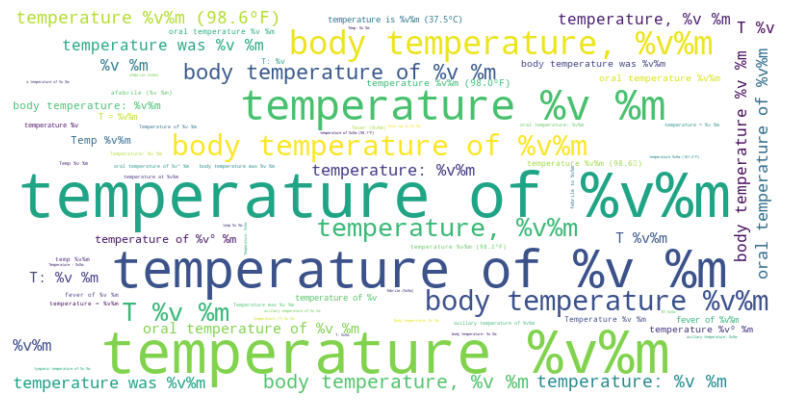

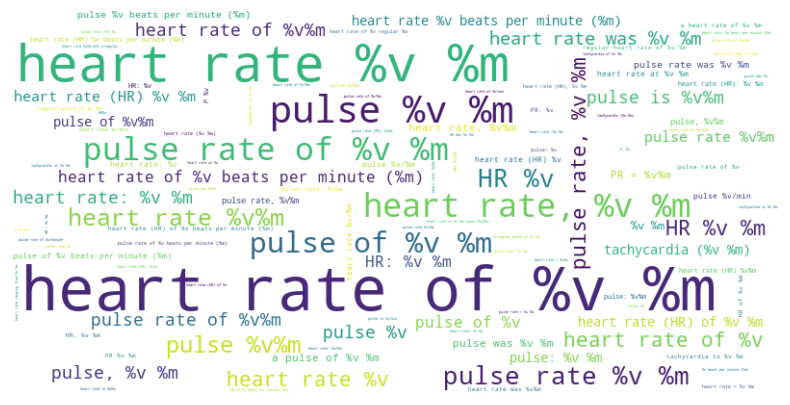

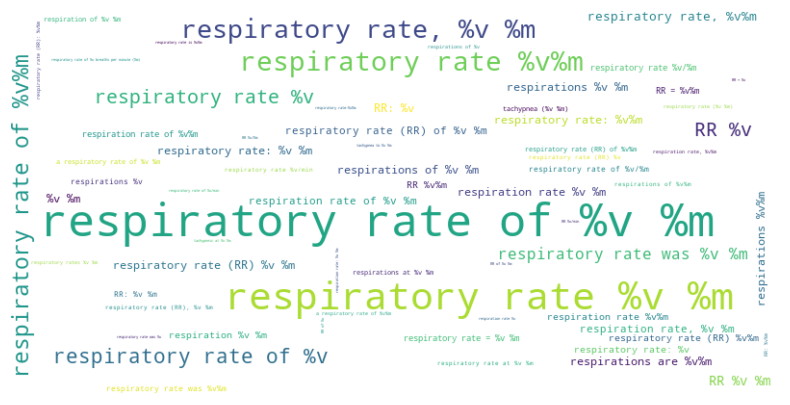

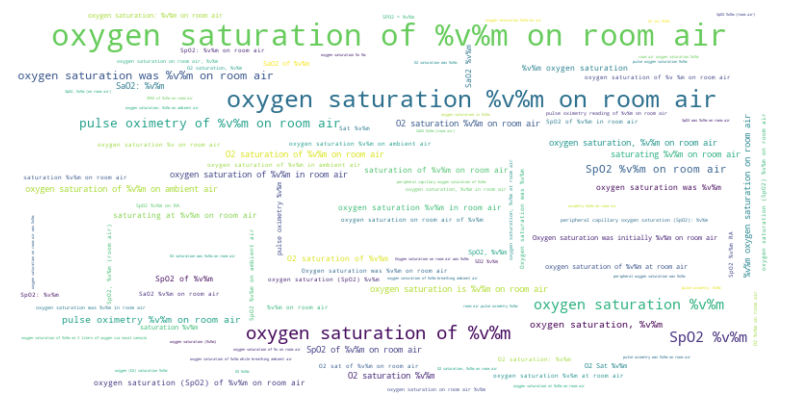

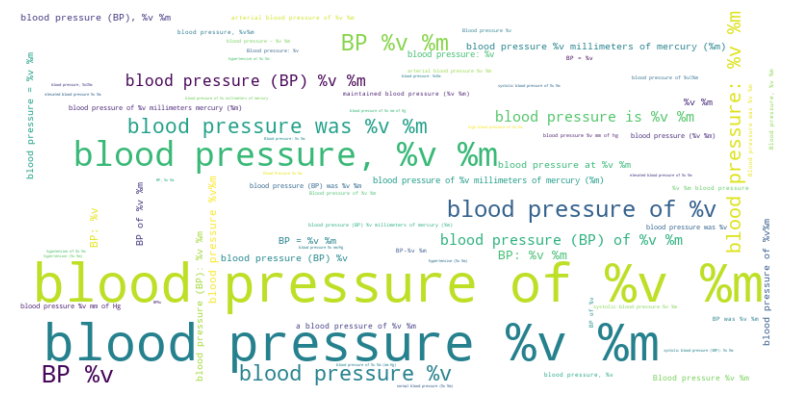

In [130]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


def plot_wordcloud(dictt):
    # Create a word cloud
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        max_words=200 # Adjust as needed
    )

    # Pass the dictionary to generate_from_frequencies
    wc.generate_from_frequencies(dictt)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.show()
    
for vital_sign in vital_signs_cols:
    # Create a word frequency dictionary
    plot_wordcloud(df[f'{vital_sign}_text'].value_counts().to_dict())

### check number of full samples

In [131]:
import re

full_value_df = df[df.apply((
    lambda x: x['temperature_text'] is not None and not isinstance(x['temperature_text'],float)
    and x['heart_rate_text'] is not None and not isinstance(x['heart_rate_text'],float)
    and x['respiratory_rate_text'] is not None and not isinstance(x['respiratory_rate_text'],float)
    and x['oxygen_saturation_text'] is not None and not isinstance(x['oxygen_saturation_text'],float)
    and x['blood_pressure_text'] is not None and not isinstance(x['blood_pressure_text'],float)
    and not bool(re.search(r'\d{2,}', x['extracted_vital_sign_text_template'].lower()))
    and ">" not in x['extracted_vital_sign_text_template'].lower()
    and "<" not in x['extracted_vital_sign_text_template'].lower()
), axis=1)]
print(full_value_df.__len__())
full_value_df.head(2)

1845


,_id,description,extracted_vital_sign_text,extracted_vital_sign_json,temperature_text,heart_rate_text,respiratory_rate_text,oxygen_saturation_text,blood_pressure_text,extracted_vital_sign_text_template
1,trec-cds-2016-20,A 87 year old female NH resident with a histor...,TM 97.9 HR 83 BP 157/92 RR 18 sat 97% RA,"{'temperature': {'text': 'TM 97.9', 'number': ...",TM %v,HR %v,RR %v,sat %v%m RA,BP %v,TM %v HR %v BP %v RR %v sat %v%m RA
4,pmc-8675570-1,We describe the case of a 55-year-old male who...,"heart rate (HR) 75, respiratory rate (RR) 29, ...",{'temperature': {'text': 'Temperature was 36.3...,Temperature was %v%m,heart rate (HR) %v,respiratory rate (RR) %v,oxygen saturation %v%m on 2L nasal cannula,blood pressure (BP) %v,"heart rate (HR) %v, respiratory rate (RR) %v, ..."


In [132]:
# plot_wordcloud(df['extracted_vital_sign_text_template'].value_counts().to_dict())
full_value_df['extracted_vital_sign_text_template'].value_counts()

extracted_vital_sign_text_template
T %v %m, HR %v, BP %v, RR %v, and SpO2 %v%m                                                                                 8
T %v %m, HR %v, BP %v, RR %v, SpO2 %v%m                                                                                     8
T: %v %m, HR: %v %m, BP: %v %m, RR: %v, SaO2: %v%m                                                                          7
temperature %v%m, pulse rate %v %m, respiratory rate %v %m, blood pressure %v %m, and oxygen saturation %v%m on room air    5
T %v, HR %v, BP %v, RR %v, SpO2 %v%m                                                                                        5
                                                                                                                           ..
BP: %v, HR: %v %m, RR: %v %m, Temperature: %v %m, and SPO2: %v%m                                                            1
temperature %v%m, HR %v, BP %v, and RR of %v with an oxygen saturation of %v%m     

In [133]:
print("Number of extracted notes: ",len(df))
print("The Repeatition Ratio of:")
print("\tfull values templates:", round(len(df)/df['extracted_vital_sign_text_template'].value_counts().__len__(), 2), f"({df['extracted_vital_sign_text_template'].value_counts().__len__()})")
print("\ttemperature template:", round(len(df)/df['temperature_text'].value_counts().__len__(), 2), f"({df['temperature_text'].value_counts().__len__()})")
print("\theart rate template:", round(len(df)/df['heart_rate_text'].value_counts().__len__(), 2), f"({df['heart_rate_text'].value_counts().__len__()})")
print("\trespiratory rate template:", round(len(df)/df['respiratory_rate_text'].value_counts().__len__(), 2), f"({df['respiratory_rate_text'].value_counts().__len__()})")
print("\toxygen saturation template:", round(len(df)/df['oxygen_saturation_text'].value_counts().__len__(), 2), f"({df['oxygen_saturation_text'].value_counts().__len__()})")
print("\tblood pressure template:", round(len(df)/df['blood_pressure_text'].value_counts().__len__(), 2), f"({df['blood_pressure_text'].value_counts().__len__()})")

Number of extracted notes:  2829
The Repeatition Ratio of:
	full values templates: 1.1 (2578)
	temperature template: 6.2 (456)
	heart rate template: 8.81 (321)
	respiratory rate template: 10.97 (258)
	oxygen saturation template: 2.9 (976)
	blood pressure template: 12.25 (231)


In [134]:
print("Number of full vital sign in notes: ",len(full_value_df))
print("The Repeatition Ratio of:")
print("\tfull values templates:", round(len(full_value_df)/full_value_df['extracted_vital_sign_text_template'].value_counts().__len__(), 2), f"({full_value_df['extracted_vital_sign_text_template'].value_counts().__len__()})")
print("\ttemperature template:", round(len(full_value_df)/full_value_df['temperature_text'].value_counts().__len__(), 2), f"({full_value_df['temperature_text'].value_counts().__len__()})")
print("\theart rate template:", round(len(full_value_df)/full_value_df['heart_rate_text'].value_counts().__len__(), 2), f"({full_value_df['heart_rate_text'].value_counts().__len__()})")
print("\trespiratory rate template:", round(len(full_value_df)/full_value_df['respiratory_rate_text'].value_counts().__len__(), 2), f"({full_value_df['respiratory_rate_text'].value_counts().__len__()})")
print("\toxygen saturation template:", round(len(full_value_df)/full_value_df['oxygen_saturation_text'].value_counts().__len__(), 2), f"({full_value_df['oxygen_saturation_text'].value_counts().__len__()})")
print("\tblood pressure template:", round(len(full_value_df)/full_value_df['blood_pressure_text'].value_counts().__len__(), 2), f"({full_value_df['blood_pressure_text'].value_counts().__len__()})")

Number of full vital sign in notes:  1845
The Repeatition Ratio of:
	full values templates: 1.06 (1742)
	temperature template: 6.86 (269)
	heart rate template: 7.59 (243)
	respiratory rate template: 9.56 (193)
	oxygen saturation template: 2.59 (713)
	blood pressure template: 11.18 (165)


In [135]:
print("Average number of words in all notes: ",int(df['description'].map(lambda x: x.split(' ').__len__()).mean()))
print("Average number of words in full vital sign notes: ",int(full_value_df['description'].map(lambda x: x.split(' ').__len__()).mean()))

Average number of words in all notes:  519
Average number of words in full vital sign notes:  523


### Sep

In [136]:
from collections import Counter


def find_sep_vital_sign(template, temp, hr, rr, spo2, bp):
    replace_value = "%t"
    if temp and not isinstance(temp, float): # nan
        template = template.replace(temp.strip(), replace_value)
    if hr and not isinstance(hr, float): # nan
        template = template.replace(hr.strip(), replace_value)
    if rr and not isinstance(rr, float): # nan
        template = template.replace(rr.strip(), replace_value)
    if spo2 and not isinstance(spo2, float): # nan
        template = template.replace(spo2.strip(), replace_value)
    if bp and not isinstance(bp, float): # nan
        template = template.replace(bp.strip(), replace_value)
    
    sep = Counter([v for v in template.split(replace_value) if v]).most_common(1)
    return sep[0][0] if sep else None

full_value_df['sep_vital_sign'] = full_value_df.apply(lambda x: find_sep_vital_sign(x['extracted_vital_sign_text_template'], x['temperature_text'], x['heart_rate_text'], x['respiratory_rate_text'], x['oxygen_saturation_text'], x['blood_pressure_text']), axis=1)
full_value_df['sep_vital_sign'].value_counts()[:5]

sep_vital_sign
,        1439
;         248
, a        83
            9
 and        5
Name: count, dtype: int64

### Map

In [ ]:
import os
import re
import pandas as pd


print(f"Num full vital sign notes can select for task:")
age_std = 2 # allow to check if existing search by age with min>=1 full_vital_sign
for task in ['retrieval', 'calculation', 'comparison','summary']:
    for subtask in os.listdir(f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}"):
        file_path = f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}/{subtask}"
        our_df = pd.read_csv(file_path)
        our_df['age'] = our_df['question'].map(lambda x: x[re.search(r'age: (\d+)', x).span()[0]+5:re.search(r'age: (\d+)', x).span()[1]]).map(lambda x: int(x)-age_std)
        our_df['mapping_num'] = our_df.age.map(lambda age: full_value_df[full_value_df['description'].str.lower().map(lambda x: bool(re.search(f'{age} year old|{age}-year-old|{age} years old|{age}-years-old|{age}-yr-old|{age} yr old', x)))].__len__())
        # print(our_df.mapping_num.value_counts().sort_index())
        # print(our_df.mapping_num.value_counts())
        print(f"\t{subtask.split('.')[0]}: min-{our_df.mapping_num.min()} max-{our_df.mapping_num.max()}")

Num full vital sign notes can select for task:
	direct_retrieval: min-2 max-35
	calculation_1step: min-3 max-40
	calculation_2step: min-3 max-40
	calculation_3step: min-1 max-40
	comparison_superlative: min-3 max-40
	comparison_comparative: min-3 max-40
	superlative: min-3 max-40
	comparative: min-3 max-40
	summary: min-3 max-40


In [142]:
full_value_df.head(2)

,_id,description,extracted_vital_sign_text,extracted_vital_sign_json,temperature_text,heart_rate_text,respiratory_rate_text,oxygen_saturation_text,blood_pressure_text,extracted_vital_sign_text_template,sep_vital_sign
1,trec-cds-2016-20,A 87 year old female NH resident with a histor...,TM 97.9 HR 83 BP 157/92 RR 18 sat 97% RA,"{'temperature': {'text': 'TM 97.9', 'number': ...",TM %v,HR %v,RR %v,sat %v%m RA,BP %v,TM %v HR %v BP %v RR %v sat %v%m RA,
4,pmc-8675570-1,We describe the case of a 55-year-old male who...,"heart rate (HR) 75, respiratory rate (RR) 29, ...",{'temperature': {'text': 'Temperature was 36.3...,Temperature was %v%m,heart rate (HR) %v,respiratory rate (RR) %v,oxygen saturation %v%m on 2L nasal cannula,blood pressure (BP) %v,"heart rate (HR) %v, respiratory rate (RR) %v, ...",","


In [143]:
age=77
full_value_df[full_value_df['description'].str.lower().map(lambda x: bool(re.search(f'{age} year old|{age}-year-old|{age} years old|{age}-years-old|{age}-yr-old|{age} yr old', x)))].extracted_vital_sign_text_template.value_counts()

extracted_vital_sign_text_template
temperature %v %m, blood pressure %v, heart rate %v %m, respiratory rate %v %m, and oxygen saturation of %v%m on room air                                       1
heart rate of %v, peripheral capillary oxygen saturation (SpO2) of %v%m, temperature of %v%m, blood pressure of %v %m, and respiratory rate of %v %m            1
temperature %v%m, heart rate %v %m, respiratory rate %v %m, blood pressure %v %m, and oxygen saturation %v%m on room air                                        1
blood pressure was %v, respiratory rate was %v, oxygen saturation obtained from the finger was %v%m on room air, pulse was %v, and temperature was %v %m        1
temperature of %v %m, heart rate of %v %m, systolic blood pressure of %v %m, respiratory rate of %v%m, saturating at %v%m on room air                           1
temperature, %v%m; heart rate, %v %m with regular rhythm; respiratory rate, %v %m; blood pressure, %v %m; and peripheral oxygen saturation, %v%m in room ai

In [ ]:
import random
from datetime import datetime


def convert_json_vital(str):
    chart_time = re.search(r'    chart_time: \d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\n', str).group(0).strip().replace('chart_time: ', '').replace(',', '')
    temperature = re.search(r'temperature: .+,', str).group(0).strip().replace('temperature: ', '').replace(',', '')
    heart_rate = re.search(r'heart_rate: .+,', str).group(0).strip().replace('heart_rate: ', '').replace(',', '')
    respiratory_rate = re.search(r'resp_rate: .+,', str).group(0).strip().replace('resp_rate: ', '').replace(',', '')
    oxygen_saturation = re.search(r'o2_sat: .+,', str).group(0).strip().replace('o2_sat: ', '').replace(',', '')
    age = re.search(r'age: \d+', str).group(0).strip().replace('age: ', '').replace(',', '')
    gender = re.search(r'gender: .+', str).group(0).strip().replace('gender: ', '').replace(',', '')
    pain = re.search(r'pain: .+', str).group(0).strip().replace('pain: ', '').replace(',', '')
    blood_pressure = re.search(r'bp: .+', str).group(0).strip().replace('bp: ', '')
    return {
        'chart_time': chart_time,
        'temperature': temperature,
        'heart_rate': heart_rate,
        'respiratory_rate': respiratory_rate,
        'oxygen_saturation': oxygen_saturation,
        'blood_pressure': blood_pressure,
        'age': age,
        'gender': gender,
        "pain": pain
    }
    
# def present_random_time(time_str):
#     date_time = datetime.strptime(time_str, '%Y-%m-%d %H:%M:%S')
    
#     return date_time.strftime('%B %d, %Y at %I:%M %p')

def substitute_question(old_question, full_value_df):
    random_state = 42
    context, question = old_question.split('\n\n')
    context = context.split('},\n')
    context = [convert_json_vital(c) for c in context]
    
    age = int(context[0]['age'])-age_std
    filtered_df = full_value_df[full_value_df['description'].str.lower().map(lambda x: bool(re.search(f'{age} year old|{age}-year-old|{age} years old|{age}-years-old|{age}-yr-old|{age} yr old', x)))].reset_index(drop=True)
    # filtered_df = filtered_df[filtered_df["extracted_vital_sign_text"].map(lambda v: len(v)>0)]
    filtered_df = filtered_df.sample(n=min(len(context), len(filtered_df)), random_state=random_state).reset_index(drop=True)
    filtered_df['extracted_vital_sign_json'] = filtered_df['extracted_vital_sign_json'].map(lambda x: eval(x) if isinstance(x, str) else x)
    
    replaced_context = []
    for i, c in enumerate(context):
        row = filtered_df.iloc[i] if i < len(filtered_df) else filtered_df.iloc[random.randint(0, len(filtered_df) - 1)]
        if i==0:
            replaced_note = row['description']
        else:
            replaced_note = row['extracted_vital_sign_text']
        for vital_sign in ["temperature", "heart_rate", "respiratory_rate", "oxygen_saturation", "blood_pressure"]:
            if vital_sign == 'temperature':
                unit = row['extracted_vital_sign_json'][vital_sign]['unit'].replace("Fahrenheit", "Celsius").replace('F', 'C') if row['extracted_vital_sign_json'][vital_sign]['unit'] else ""
            else:
                unit = row['extracted_vital_sign_json'][vital_sign]['unit'] or ""
            try:
                replaced_note = replaced_note.replace(row['extracted_vital_sign_json'][vital_sign]['text'], row[f'{vital_sign}_text'].replace('%v', c[vital_sign]).replace('%m',  unit))
            except:
                print(row['extracted_vital_sign_json'][vital_sign])
                print(c[vital_sign])
                print(replaced_note)
                print(row[f'{vital_sign}_text'])

                raise Exception("Error")
        replaced_context.append(f"At {c['chart_time']}, " + replaced_note)
            
    new_question = '. '.join(replaced_context) + '\n\n' + question
    return new_question

# our_df['question'].map(lambda x: substitute_question(x, full_value_df))

In [147]:
root_out_dir = "/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data"
out_dir = f"{root_out_dir}/natural/"
os.makedirs(out_dir, exist_ok=True)
for task in ['retrieval', 'calculation', 'comparison','summary']:
    os.makedirs(os.path.join(out_dir, task), exist_ok=True)
    for subtask in os.listdir(f"{root_out_dir}/structured/{task}"):
        file_path = f"{root_out_dir}/structured/{task}/{subtask}"
        our_df = pd.read_csv(file_path)
        our_df['question'] = our_df['question'].map(lambda x: substitute_question(x, full_value_df))
        our_df.to_csv(os.path.join(out_dir, task, subtask), index=False)

#### Check tree visualization

In [148]:
def tree_visualize(vital_sign, abbr, full):
    def length_cat_fn(x):
        if full in x.lower():
            return 'full'
        # elif bool(re.search(abbr, x.lower())):
        #     return ''
        else:
            return 'abbr'

    def seporator_fn(x):
        checked_text = x[x.find("%v")-2:x.find("%v")].strip()
        if x.find("%v")==-1 or not checked_text or checked_text.isalpha() or checked_text==")" or checked_text=="]" or checked_text=="%m" or checked_text=="2":
            return "space"
        elif checked_text[0].isalpha() or checked_text[0] in [")", "]"]:
            if checked_text[1]==" ":
                return "space"
            return checked_text[1:]
        else:
            return checked_text
        
    bp_df = full_value_df[full_value_df[f'{vital_sign}_text'].notna()]
    bp_df['length_cat'] = bp_df[f'{vital_sign}_text'].map(length_cat_fn)
    # bp_df = bp_df[bp_df['length_cat']!="other"]
    bp_df['has_unit'] = bp_df[f'{vital_sign}_text'].map(lambda x: '%m' in x.lower())
    bp_df['sep'] = bp_df[f'{vital_sign}_text'].map(seporator_fn)
    bp_df = bp_df[bp_df['sep'].isin(bp_df['sep'].value_counts()[bp_df['sep'].value_counts()>2].index)]
    bp_df['sep'].value_counts()
    bp_df['has_unit'] = bp_df['has_unit'].map(lambda x: 'has unit' if x else 'no unit')
    # bp_df['length_cat'] = bp_df['length_cat'].map(lambda x: 'combined' if x=='combined' else 'full' if x=='long' else 'abbr')
    bp_df['sep'] = bp_df['sep'].map(lambda x: 'comma' if x==',' else 'colon' if x==':' else x)
    # print(bp_df[bp_df['sep']=='2'])

    grouped_df = bp_df.groupby(['length_cat', 'has_unit', 'sep']).size().reset_index(name='Count')
    return grouped_df, vital_sign

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Collect data for all vital signs
vital_signs_data = []
vital_signs = [
    ("blood_pressure", "bp", "blood pressure"),
    ("temperature", "temp", "temperature"),
    ("heart_rate", "hr", "heart rate"),
    ("respiratory_rate", "rr", "respiratory rate"),
    ("oxygen_saturation", r"spo2|o2sat", "oxygen saturation")
]

for vital_sign, abbr, full in vital_signs:
    grouped_df, name = tree_visualize(vital_sign, abbr, full)
    vital_signs_data.append((grouped_df, name))

# Create subplots with 5 sunburst charts
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"type": "domain"}, {"type": "domain"}, {"type": "domain"}], [{"type": "domain"}, {"type": "domain"}, {"type": "domain"}]],
    subplot_titles=[name.replace('_', ' ').title() for _, name in vital_signs_data]
)

for i, (grouped_df, name) in enumerate(vital_signs_data):
    sunburst = px.sunburst(grouped_df, path=['length_cat', 'has_unit', 'sep'], values='Count')
    fig.add_trace(sunburst.data[0], row=i//3+1, col=i%3+1)

fig.update_layout(
    title_text="Vital Signs Template Variation Distribution",
    height=600,
    width=1000
)
fig.show()


In [149]:
import re

def length_cat_fn(x):
    if len(x)<=70:
        return 'abbr'
    else:
        return 'full'

def seporator_fn(x):
    checked_text = x[x.find("%v")-2:x.find("%v")].strip()
    if x.find("%v")==-1 or not checked_text or checked_text.isalpha() or checked_text==")" or checked_text=="]" or checked_text=="%m":
        return "space"
    elif checked_text[0].isalpha() or checked_text[0] in [")", "]"]:
        if checked_text[1]==" ":
            return "space"
        return checked_text[1:]
    else:
        return checked_text
    
bp_df = full_value_df[full_value_df['extracted_vital_sign_text_template'].notna()]
bp_df['length_cat'] = bp_df['extracted_vital_sign_text_template'].map(length_cat_fn)
bp_df['has_unit'] = bp_df['extracted_vital_sign_text_template'].map(lambda x: len(re.findall(r'%m', x)) >= 4)
# bp_df['sep'] = bp_df['extracted_vital_sign_text_template'].map(seporator_fn)
# bp_df = bp_df[bp_df['sep'].isin(bp_df['sep'].value_counts()[bp_df['sep'].value_counts()>2].index)]
bp_df.groupby(['length_cat', 'has_unit']).size().reset_index(name='Count')

,length_cat,has_unit,Count
0,abbr,False,77
1,abbr,True,68
2,full,False,168
3,full,True,1532


In [150]:
bp_df[bp_df['length_cat']=='full']

,_id,description,extracted_vital_sign_text,extracted_vital_sign_json,temperature_text,heart_rate_text,respiratory_rate_text,oxygen_saturation_text,blood_pressure_text,extracted_vital_sign_text_template,sep_vital_sign,length_cat,has_unit
4,pmc-8675570-1,We describe the case of a 55-year-old male who...,"heart rate (HR) 75, respiratory rate (RR) 29, ...",{'temperature': {'text': 'Temperature was 36.3...,Temperature was %v%m,heart rate (HR) %v,respiratory rate (RR) %v,oxygen saturation %v%m on 2L nasal cannula,blood pressure (BP) %v,"heart rate (HR) %v, respiratory rate (RR) %v, ...",",",full,False
8,pmc-8675596-2,A 58-year-old female with no significant past ...,"BP 105/96, HR 131 bpm, RR 20 breaths/min, oxyg...",{'temperature': {'text': 'temperature of 102.0...,temperature of %v%m,HR %v %m,RR %v %m,oxygen saturation of %v on room air,BP %v,"BP %v, HR %v %m, RR %v %m, oxygen saturation o...",",",full,False
18,pmc-8654060-1,We present the case of a 42-year-old man who p...,"tachycardia (115 bpm), low-grade fever (37.5℃)...",{'temperature': {'text': 'low-grade fever (37....,low-grade fever (%v%m),tachycardia (%v %m),normal respiratory rate (%v %m),oxygen saturation was %v on room air,maintained blood pressure (%v %m),"tachycardia (%v %m), low-grade fever (%v%m), n...",",",full,True
19,pmc-8654068-1,A 15-year-old female patient was referred by a...,"heart rate of 114 beats per minute, respirator...",{'temperature': {'text': 'temperature of 36 °C...,temperature of %v %m,heart rate of %v %m,respiratory rate of %v %m,oxygen saturation (SpO2) of %v%m in room air,blood pressure of %v %m,"heart rate of %v %m, respiratory rate of %v %m...",",",full,True
20,pmc-8654109-2,Another 34-year-old male patient who smoked vi...,BP: 126/76; PR: 43; RR: 21/min; body temperatu...,{'temperature': {'text': 'body temperature: 36...,body temperature: %v%m,PR: %v,RR: %v%m,oxygen saturation (SpO2): %v%m,BP: %v,BP: %v; PR: %v; RR: %v%m; body temperature: %v...,;,full,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9896,usmle-10915,A 29-year-old computer programmer presents to ...,"temperature 36.9°C, blood pressure 100/65, hea...","{'temperature': {'text': 'temperature 36.9°C',...",temperature %v%m,heart rate %v,respiratory rate %v,oxygen saturation of %v%m,blood pressure %v,"temperature %v%m, blood pressure %v, heart rat...",",",full,False
9898,usmle-10938,A 33-year-old Honduran woman presents to your ...,"temperature 37 degrees Celsius, blood pressure...",{'temperature': {'text': 'temperature 37 degre...,temperature %v %m,heart rate %v%m,respiratory rate %v%m,oxygen saturation %v%m on room air,blood pressure %v %m,"temperature %v %m, blood pressure %v %m, heart...",",",full,True
9906,usmle-11055,A 64-year-old male with a past medical history...,"temperature 37° C, HR 110, BP 149/87, and RR o...","{'temperature': {'text': 'temperature 37° C', ...",temperature %v%m,HR %v,RR of %v,oxygen saturation of %v%m,BP %v,"temperature %v%m, HR %v, BP %v, and RR of %v w...",",",full,False
9923,usmle-12065,A 39-year-old female with a long history of ma...,"temperature 38.1 degrees Celsius, heart rate 1...",{'temperature': {'text': 'temperature 38.1 deg...,temperature %v %m,heart rate %v %m,respiratory rate %v,oxygen saturation %v%m on room air,blood pressure %v,"temperature %v %m, heart rate %v %m, blood pre...",",",full,False


# Create ablation study: check change in change variant

In [151]:
import random

atts = ["heart rate {heartrate} bpm", "temperature {temperature}°C", "respiratory rate {resprate} bpm", "O2 saturation {o2sat}%", "blood pressure {bp} mmHg"]
order_var = ["At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is "+', '.join(random.sample(atts, len(atts)))+"." for _ in range(10)]
var_check_templates = {
    "abbr": [
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}°C, hh {heartrate} bpm, rr {resprate} bpm, spo2 {o2sat}%, bp {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}°C, hh {heartrate} bpm, rr {resprate} bpm, o2sat {o2sat}%, bp {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is Temp {temperature}°C, hh {heartrate} bpm, rr {resprate} bpm, o2sat {o2sat}%, bp {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}°C, HH {heartrate} bpm, RR {resprate} bpm, SpO2 {o2sat}%, BP {bp} mmHg.",
    ],
    "no_unit": [
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time includes a temperature of {temperature}, a heart rate of {heartrate}, a respiratory rate of {resprate}, and a oxygen saturation of {o2sat}, and a blood pressure of {bp}.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time includes a temperature of {temperature}, a heart rate of {heartrate}, a respiratory rate of {resprate}, and a oxygen saturation of {o2sat}%, and a blood pressure of {bp}.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time includes a temperature of {temperature}, a heart rate of {heartrate}, a respiratory rate of {resprate}, and a oxygen saturation of {o2sat}, and a blood pressure of {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time includes a temperature of {temperature}°C, a heart rate of {heartrate}, a respiratory rate of {resprate} bpm, and a oxygen saturation of {o2sat}, anda blood pressure of {bp}.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time includes a temperature of {temperature}, a heart rate of {heartrate} bpm, a respiratory rate of {resprate}, and a oxygen saturation of {o2sat}, anda blood pressure of {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time includes a temperature of {temperature}, a heart rate of {heartrate} bpm, a respiratory rate of {resprate}, and a oxygen saturation of {o2sat}, anda blood pressure of {bp}.",
    ],
    "abbr_no_unit": [
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}, hh {heartrate} bpm, rr {resprate}, spo2 {o2sat}, bp {bp}.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}, hh {heartrate}, rr {resprate}, spo2 {o2sat}, bp {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}, hh {heartrate} bpm, rr {resprate}, spo2 {o2sat}, bp {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}, hh {heartrate}, rr {resprate}, o2sat {o2sat}, bp {bp}.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is Temp {temperature}, hh {heartrate}, rr {resprate} bpm, o2sat {o2sat}, bp {bp}.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}°C, HH {heartrate}, RR {resprate}, SpO2 {o2sat}%, BP {bp}.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is T {temperature}, HH {heartrate}, RR {resprate}, SpO2 {o2sat}%, BP {bp}.",
    ],
    "sep": [
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is temperature, {temperature}°C; heart rate, {heartrate} bpm; respiratory rate, {resprate} bpm; O2 saturation, {o2sat}%; blood pressure, {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is temperature: {temperature}°C; heart rate: {heartrate} bpm; respiratory rate: {resprate} bpm; O2 saturation: {o2sat}%; blood pressure: {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is temperature: {temperature}°C, heart rate: {heartrate} bpm, respiratory rate: {resprate} bpm, O2 saturation: {o2sat}%, blood pressure: {bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time is temperature-{temperature}°C, heart rate-{heartrate} bpm, respiratory rate-{resprate} bpm, O2 saturation-{o2sat}%, blood pressure-{bp} mmHg.",
        "At {charttime}, the {age}-year-old {gender} reports pain level is {pain}. {possessive_pronoun} vital sign at the time includes a temperature-{temperature}°C, a heart rate-{heartrate} bpm, a respiratory rate-{resprate} bpm, a O2 saturation-{o2sat}%, and a blood pressure-{bp} mmHg.",
    ],
    "order":order_var
}

In [152]:
def substitute_question_var(old_question, templates):
    
    context, question = old_question.split('\n\n')
    context = context.split('},\n')
    context = [convert_json_vital(c) for c in context]
    age = context[0]['age']
    
    replaced_context = []
    for i, c in enumerate(context):
        template = random.choice(templates)
        gender = random.choice(["male", "boy" if int(age)<18 else "man"]) if context[0]['gender']=="male" else random.choice(["female", "girl" if int(age)<18 else "woman"])
    
        replaced_note = template.format(
            charttime=c['chart_time'],
            age=age,
            gender=gender,
            pain=c['pain'],
            possessive_pronoun="her" if gender=="female" else "his",
            temperature=c['temperature'],
            heartrate=c['heart_rate'],
            resprate=c['respiratory_rate'],
            o2sat=c['oxygen_saturation'],
            bp=c['blood_pressure'],
        )
        replaced_context.append(replaced_note)
            
    new_question = ' '.join(replaced_context) + '\n\n' + question
    return new_question

In [153]:
import os 
import pandas as pd 

out_dir = "/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/ablation_var_sum/"

os.makedirs(out_dir, exist_ok=True)
for task in ['summary']:
    for k, v in var_check_templates.items():
        os.makedirs(os.path.join(out_dir, task, k), exist_ok=True)
        for subtask in os.listdir(f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}"):
            file_path = f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}/{subtask}"
            our_df = pd.read_csv(file_path)
            our_df['question'] = our_df['question'].map(lambda x: substitute_question_var(x, v))
            our_df.to_csv(os.path.join(out_dir, task, f"{k}.csv"), index=False)

In [154]:
import os 
import pandas as pd 
import re

out_dir = "/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/ablation_var_comparison/"

os.makedirs(out_dir, exist_ok=True)
for task in ['comparison']:
    for k, v in var_check_templates.items():
        os.makedirs(os.path.join(out_dir, task, k), exist_ok=True)
        for subtask in os.listdir(f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}"):
            file_path = f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}/{subtask}"
            our_df = pd.read_csv(file_path)
            our_df['question'] = our_df['question'].map(lambda x: substitute_question_var(x, v))
            our_df.to_csv(os.path.join(out_dir, task, f"{k}.csv"), index=False)

In [155]:
import os 
import pandas as pd 
import re

out_dir = "/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/ablation_var_calc/"

os.makedirs(out_dir, exist_ok=True)
for task in ['calculation']:
    for k, v in var_check_templates.items():
        os.makedirs(os.path.join(out_dir, task, k), exist_ok=True)
        for subtask in os.listdir(f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}"):
            file_path = f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}/{subtask}"
            our_df = pd.read_csv(file_path)
            our_df['question'] = our_df['question'].map(lambda x: substitute_question_var(x, v))
            our_df.to_csv(os.path.join(out_dir, task, f"{k}.csv"), index=False)

In [156]:
import os 
import pandas as pd 
import re

out_dir = "/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/ablation_var_retrieval/"

os.makedirs(out_dir, exist_ok=True)
for task in ['retrieval']:
    for k, v in var_check_templates.items():
        os.makedirs(os.path.join(out_dir, task, k), exist_ok=True)
        for subtask in os.listdir(f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}"):
            file_path = f"/Users/vuong/Downloads/research/repos/ClinicNumRobBench/data/structured/{task}/{subtask}"
            our_df = pd.read_csv(file_path)
            our_df['question'] = our_df['question'].map(lambda x: substitute_question_var(x, v))
            our_df.to_csv(os.path.join(out_dir, task, f"{k}.csv"), index=False)